<a href="https://colab.research.google.com/github/lalitha-sahitya/Rainfall-prediction/blob/main/rainfall_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [317]:
import os

In [318]:
!pip install opendatasets

In [319]:
import warnings
warnings.filterwarnings('ignore')


In [320]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/abhishek1405/rainfall-prediction')

Skipping, found downloaded files in "./rainfall-prediction" (use force=True to force download)


In [321]:
os.listdir('rainfall-prediction')

['dataset1.csv']

In [322]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [323]:
data=pd.read_csv('/content/rainfall-prediction/dataset1.csv')
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [324]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [325]:
data.isna().sum()

,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0


In [326]:
rain={'yes':1,'no':0}
data['rainfall']=data['rainfall'].map(rain)

In [327]:
for i in data.columns:
  fig=px.histogram(data,x=i,color='rainfall')
  fig.show()

In [328]:
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [329]:
data.day.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [330]:
data.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [331]:
data['         winddirection'] = data['         winddirection'].fillna(data['         winddirection'].median())


In [332]:
data['windspeed']=data['windspeed'].fillna(data['windspeed'].median())

In [333]:
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [334]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    int64  
 9   sunshine                366 non-null    float64
 10           winddirection  366 non-null    float64
 11  windspeed               366 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 34.4 KB


In [335]:
x=data.drop('rainfall',axis=1)
y=data['rainfall']

In [336]:
from sklearn.model_selection import train_test_split

In [337]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [338]:
x_test.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
193,12,1003.8,29.0,28.1,27.0,25.1,84,88,0.0,230.0,16.3
33,3,1023.6,14.3,12.5,10.3,8.6,77,88,0.3,40.0,21.3
15,16,1013.5,17.1,16.4,15.5,15.6,95,93,0.0,60.0,40.0
310,6,1015.6,26.3,25.5,24.7,22.4,83,81,0.5,80.0,30.2
57,27,1024.7,17.5,15.5,13.8,11.7,79,79,5.0,20.0,9.1


In [339]:
x_train.shape

(292, 11)

In [340]:
x_test.shape

(74, 11)

In [341]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [342]:
x_train=pd.DataFrame(x_train,columns=x.columns)
x_test=pd.DataFrame(x_test,columns=x.columns)

In [343]:
x_test.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,-0.434893,-1.557545,0.409515,0.723261,0.869622,0.804386,0.366463,0.812684,-1.180085,1.560918,-0.507869
1,-1.461758,1.649057,-2.107743,-2.105448,-2.171125,-2.006822,-0.331626,0.812684,-1.104491,-0.793615,0.003432
2,0.021491,0.013366,-1.628266,-1.398271,-1.224305,-0.814188,1.463459,1.037915,-1.180085,-0.545769,1.915700
3,-1.119470,0.353461,-0.052839,0.251809,0.450837,0.344370,0.266736,0.497360,-1.054094,-0.297924,0.913549
4,1.276547,1.827202,-1.559769,-1.561465,-1.533842,-1.478656,-0.132172,0.407268,0.079823,-1.041460,-1.244144


In [344]:
x_train.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,-1.005374,1.568082,-1.251533,-1.235076,-1.242513,-1.410505,-0.830261,0.722591,-0.953302,-1.165383,0.054562
1,0.591971,-0.407703,1.145856,1.067783,0.960663,0.838461,-0.431353,-0.944120,1.037353,1.436995,-0.916911
2,0.021491,0.256291,-1.765259,-1.597731,-1.479218,-1.154941,0.964824,1.353239,-1.180085,-0.545769,1.220330
3,1.048355,1.697642,-1.868004,-1.887855,-1.934420,-1.904597,-0.531080,0.812684,-1.129689,-1.041460,-0.190863
4,0.477875,1.470913,-1.371402,-1.180678,-0.951184,-1.274204,-0.531080,0.812684,-1.180085,-0.793615,-0.231767


In [345]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [346]:
preds=model.predict(x_test)

In [347]:
preds

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1])

In [348]:
from sklearn.metrics import accuracy_score

In [349]:
accuracy_score(y_test,preds)

0.7972972972972973

In [350]:
import numpy as np
import pandas as pd

def predict_input(input_data):
    # Ensure the input is in the correct shape
    input_array = np.array(input_data).reshape(1, -1)
    input_df = pd.DataFrame(input_array, columns=x.columns)
    input_scaled = sc.transform(input_df)
    pred = model.predict(input_scaled)
    if pred[0] == 0:
        print('No Rainfall')
    else:
        print('Rainfall')


In [351]:
input=[5,1015.9	,21.3,	20.7,	20.2,19.9,	95,	81,0.0,	40.0,	13.7]

In [352]:
predict_input(input)

Rainfall


In [354]:
from sklearn.metrics import confusion_matrix
matrix=confusion_matrix(y_test,preds)
matrix

array([[11, 12],
       [ 3, 48]])

<Axes: >

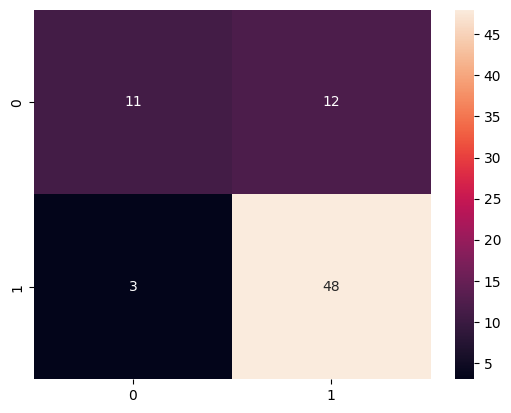

In [355]:
sns.heatmap(matrix,annot=True)